In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN

# 1 DataFrame
df1 = pd.read_csv("ejercicio_1_zonas_entrega.csv")

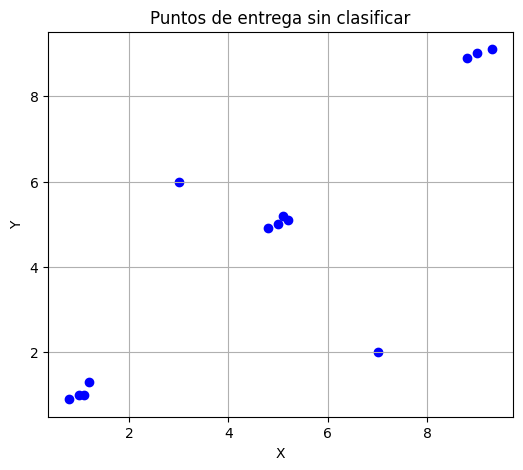

In [2]:
# 2 Graficar 
plt.figure(figsize=(6, 5))
plt.scatter(df1["X"], df1["Y"], c="blue")
plt.title("Puntos de entrega sin clasificar")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.show()

In [3]:
# 3 Aplicar DBSCAN
db1 = DBSCAN(eps=0.8, min_samples=3)
df1["Cluster"] = db1.fit_predict(df1[["X", "Y"]])

print(df1)

   Punto    X    Y  Cluster
0     P1  1.0  1.0        0
1     P2  1.2  1.3        0
2     P3  0.8  0.9        0
3     P4  1.1  1.0        0
4     P5  5.0  5.0        1
5     P6  5.2  5.1        1
6     P7  4.8  4.9        1
7     P8  5.1  5.2        1
8     P9  9.0  9.0        2
9    P10  9.3  9.1        2
10   P11  8.8  8.9        2
11   P12  3.0  6.0       -1
12   P13  7.0  2.0       -1


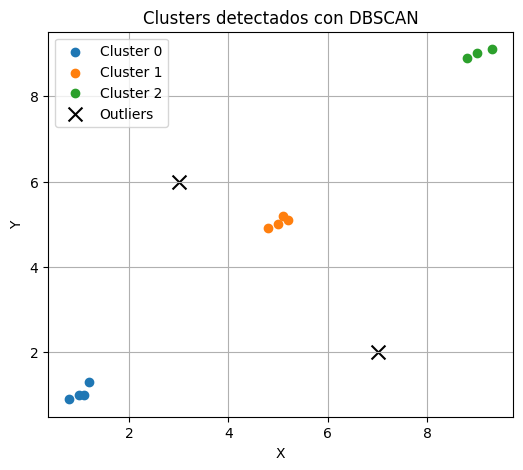

In [4]:
# 5  clusters y outliers 
plt.figure(figsize=(6, 5))

clusters = df1["Cluster"].unique()
for c in clusters:
    subset = df1[df1["Cluster"] == c]
    if c == -1:
        plt.scatter(subset["X"], subset["Y"], c="black", label="Outliers", marker="x", s=100)
    else:
        plt.scatter(subset["X"], subset["Y"], label=f"Cluster {c}")

plt.title("Clusters detectados con DBSCAN")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.legend()
plt.show()

In [5]:
# 6 ¿Cuántas zonas de entrega identificó?
num_zonas = len(set(df1["Cluster"])) - (1 if -1 in df1["Cluster"].values else 0)
print("Zonas de entrega identificadas:", num_zonas)


Zonas de entrega identificadas: 3
